In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [22]:
input_img = cv.imread('../../../class.vision/images/input.jpg', 0)
input_small_img = cv.imread('../../../class.vision/images/input-small.jpg',0)

hcs_img1 = cv.imread("../../../class.vision/images/Histogram_Comparison_Source_0.jpg")
hcs_img2 = hcs_img1[hcs_img1.shape[0]//2:,...]
hcs_img3 = cv.imread("../../../class.vision/images/Histogram_Comparison_Source_1.jpg")
hcs_img4 = cv.imread("../../../class.vision/images/Histogram_Comparison_Source_2.jpg")

Bigger image (600, 800)
Small image (300, 400)


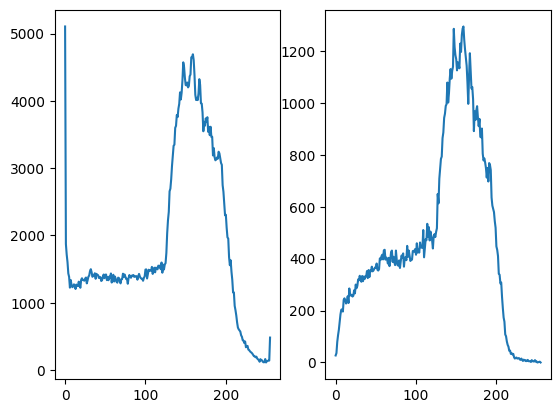

In [15]:
hist1 = cv.calcHist([input_img], [0], None, [256], [0,256])
hist2 = cv.calcHist([input_small_img], [0], None, [256], [0,256])

print("Bigger image", input_img.shape)
print("Small image", input_small_img.shape)

plt.subplot(121); plt.plot(hist1)
plt.subplot(122); plt.plot(hist2)

Best Score: 0.0
H1,H2  Score: 0.10677939461361144


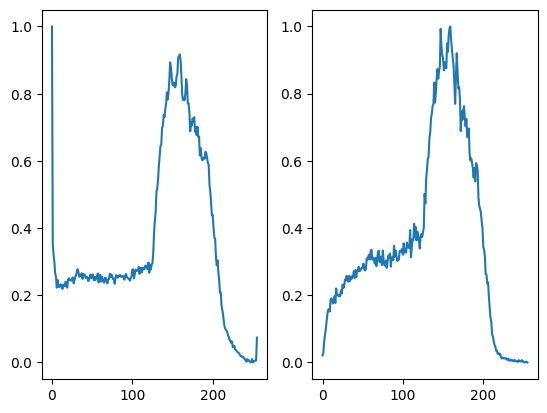

In [21]:
hist1 = cv.calcHist([input_img], [0], None, [256], [0,256])
hist2 = cv.calcHist([input_small_img], [0], None, [256], [0,256])

cv.normalize(hist1, hist1, 0, 1, cv.NORM_MINMAX)
cv.normalize(hist2, hist2, 0, 1, cv.NORM_MINMAX)

plt.subplot(121); plt.plot(hist1)
plt.subplot(122); plt.plot(hist2)

print("Best Score:", cv.compareHist(hist1, hist1, method=cv.HISTCMP_BHATTACHARYYA))
print("H1,H2  Score:", cv.compareHist(hist1, hist2, method=cv.HISTCMP_BHATTACHARYYA))

Method: HISTCMP_BHATTACHARYYA
- 0: 0.0
- 1: 0.26206663849172757
- 2: 0.32625698465671915
- 3: 0.9110825158766235
---------------
Method: HISTCMP_CHISQR
- 0: 0.0
- 1: 14325.073939327263
- 2: 33861.864108010865
- 3: 2156665.402059751
---------------
Method: HISTCMP_CHISQR_ALT
- 0: 0.0
- 1: 24116.514802167043
- 2: 26763.585316933473
- 3: 142355.53694488364
---------------
Method: HISTCMP_CORREL
- 0: 1.0
- 1: 0.6152557636459982
- 2: 0.5106019482751555
- 3: -0.21249450758907662
---------------
Method: HISTCMP_HELLINGER
- 0: 0.0
- 1: 0.26206663849172757
- 2: 0.32625698465671915
- 3: 0.9110825158766235
---------------
Method: HISTCMP_INTERSECT
- 0: 40000.0
- 1: 20000.0
- 2: 23701.0
- 3: 1619.0
---------------
Method: HISTCMP_KL_DIV
- 0: 0.0
- 1: 40932.5356850789
- 2: 65545.55559337306
- 3: 1091586.5756259852
---------------


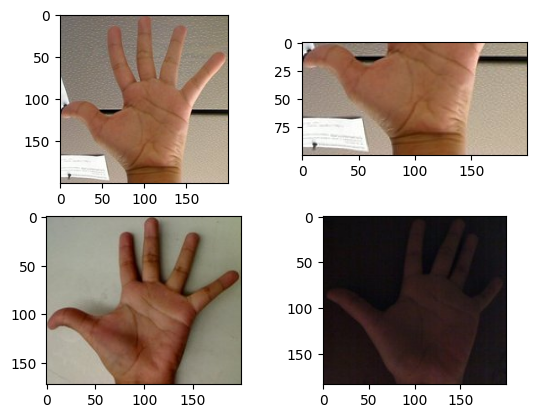

In [29]:
base = cv.calcHist([hcs_img1], [0], None, [256], [0,256])
others = [base] + [
    cv.calcHist([i], [0], None, [256], [0,256]) for i in [hcs_img2, hcs_img3, hcs_img4]
]

for method in ['HISTCMP_BHATTACHARYYA',
 'HISTCMP_CHISQR',
 'HISTCMP_CHISQR_ALT',
 'HISTCMP_CORREL',
 'HISTCMP_HELLINGER',
 'HISTCMP_INTERSECT',
 'HISTCMP_KL_DIV']:
    print("Method:", method)
    for idx, other in enumerate(others):
        res = cv.compareHist(base, other, getattr(cv, method))
        print(f"- {idx}:", res)
    print("-"*15)

plt.subplot(221); plt.imshow(hcs_img1[...,::-1])
plt.subplot(222); plt.imshow(hcs_img2[...,::-1])
plt.subplot(223); plt.imshow(hcs_img3[...,::-1])
plt.subplot(224); plt.imshow(hcs_img4[...,::-1])